# Fourier Series & Fourier Transform — Properties Workbook

CSE 220 (Signals and Linear Systems). Every property that has shown up in the
online exams, plus the ones that plausibly could, each with a short explanation
and a runnable demo.

**Ground rules used throughout, taken from the exam PDFs:**

- `np.fft`, `scipy.fft`, or any built-in DFT/FFT is **not allowed**.
- All integration is `np.trapezoid` (`np.trapz` on older numpy).
- Everything is built out of a small set of reusable classes, defined once in
  Section 1. Transformations go through the class (`x.time_shift(2)`), never by
  slicing or rolling arrays by hand — several PDFs demand this explicitly.

**Conventions.** Frequency `f` is in **Hz**, not rad/s, so the transform pair is

$$X(f)=\int_{-\infty}^{\infty} x(t)\,e^{-j2\pi f t}\,dt
\qquad
x(t)=\int_{-\infty}^{\infty} X(f)\,e^{+j2\pi f t}\,df$$

If a question gives you $\omega$ (rad/s), convert with $f=\omega/2\pi$. Getting
this wrong is the single most common way to produce a plot that looks right but
is off by a factor of $2\pi$.

### How to use this
Run Section 1 once, then jump to whichever property you need. Every section is
independent after that.

| Section | Contents |
|---|---|
| 1 | The reusable toolkit — `Signal`, `SignalGenerator`, `CFTAnalyzer`, `FourierSeries`, plotting helpers |
| 2 | The standard signal library and what each spectrum looks like |
| 3 | Forward + inverse CFT, and choosing the frequency range |
| 4 | **Fourier transform properties** (13 of them) |
| 5 | **Fourier series properties** + identifying components |
| 6 | 2D CFT on images — filtering, edges, denoising |
| 7 | Numerical gotchas checklist |

---
## 1. The reusable toolkit

Four classes and a handful of helpers. This is the block worth copying into an
exam file.

**`Signal` holds a *callable*, not just an array.** That is the whole trick: a
time shift becomes `lambda tau: func(tau - t0)`, so the function is re-sampled
on the same grid rather than the array being rolled. It also makes shifts and
scales exact instead of interpolated, and it satisfies the "do not manually
shift arrays" instruction.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (11, 3.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


# ----------------------------------------------------------------- #
# Signal: a callable plus the grid it is sampled on                  #
# ----------------------------------------------------------------- #
class Signal:
    def __init__(self, t, func, name="x(t)"):
        self.t = np.asarray(t, dtype=float)
        self.func = func
        self.name = name
        self.values = np.asarray(func(self.t))

    @classmethod
    def from_values(cls, t, values, name="x(t)"):
        # for signals that only exist as samples (a numerical derivative,
        # a convolution result). shifting one of these interpolates.
        t = np.asarray(t, float)
        v = np.asarray(values)
        if np.iscomplexobj(v):
            f = lambda tau: (np.interp(tau, t, v.real, left=0, right=0)
                             + 1j * np.interp(tau, t, v.imag, left=0, right=0))
        else:
            f = lambda tau: np.interp(tau, t, v, left=0, right=0)
        return cls(t, f, name)

    def _new(self, func, name):
        return Signal(self.t, func, name)

    # --- algebra ---
    def __add__(self, o):
        return self._new(lambda u: self.func(u) + o.func(u), f"{self.name} + {o.name}")

    def __sub__(self, o):
        return self._new(lambda u: self.func(u) - o.func(u), f"{self.name} - {o.name}")

    def __mul__(self, o):
        if isinstance(o, Signal):
            return self._new(lambda u: self.func(u) * o.func(u), f"{self.name}*{o.name}")
        return self._new(lambda u: o * self.func(u), f"{o}*{self.name}")

    __rmul__ = __mul__

    # --- transformations (each one is a property demo) ---
    def time_shift(self, t0):
        """x(t - t0)"""
        return self._new(lambda u: self.func(u - t0), f"{self.name} shifted {t0:+g}")

    def time_scale(self, a):
        """x(a*t) -- compresses when |a|>1, stretches when |a|<1"""
        return self._new(lambda u: self.func(a * u), f"{self.name} scaled a={a:g}")

    def time_reverse(self):
        """x(-t)"""
        return self._new(lambda u: self.func(-u), f"{self.name} reversed")

    def modulate(self, f0):
        """x(t)*exp(+j2*pi*f0*t) -- shifts the spectrum to +f0"""
        return self._new(lambda u: self.func(u) * np.exp(2j * np.pi * f0 * u),
                         f"{self.name} modulated {f0:g}Hz")

    def multiply_by_t(self):
        """t*x(t)"""
        return self._new(lambda u: u * self.func(u), f"t*{self.name}")

    def conjugate(self):
        return self._new(lambda u: np.conj(self.func(u)), f"conj({self.name})")

    def derivative(self):
        """numerical d/dt on the stored grid"""
        return Signal.from_values(self.t, np.gradient(self.values, self.t),
                                  f"d/dt {self.name}")

    def integral(self):
        """running integral from t[0]"""
        dt = self.t[1] - self.t[0]
        c = np.concatenate([[0], np.cumsum(0.5 * (self.values[1:] + self.values[:-1]) * dt)])
        return Signal.from_values(self.t, c, f"int {self.name}")

    def convolve(self, other):
        """(x * y)(t), same grid. needs a uniform, symmetric, odd-length grid."""
        dt = self.t[1] - self.t[0]
        c = np.convolve(self.values, other.values, mode="same") * dt
        return Signal.from_values(self.t, c, f"{self.name} * {other.name}")

In [2]:
# ----------------------------------------------------------------- #
# SignalGenerator: the standard library of test functions            #
# ----------------------------------------------------------------- #
class SignalGenerator:
    def __init__(self, t):
        self.t = t

    def _S(self, f, name):
        return Signal(self.t, f, name)

    # ---- aperiodic: these have an ordinary CFT ----
    def rect(self, width=2.0, amp=1.0):
        h = width / 2
        return self._S(lambda u: amp * np.where(np.abs(u) <= h, 1.0, 0.0),
                       f"rect(w={width:g})")

    def triangle(self, width=4.0, amp=1.0):
        h = width / 2
        return self._S(lambda u: amp * np.where(np.abs(u) <= h, 1 - np.abs(u) / h, 0.0),
                       f"tri(w={width:g})")

    def parabola(self, half=2.0):
        # y = t^2 on [-half, half], 0 outside  (from the FT practice sheet)
        return self._S(lambda u: np.where(np.abs(u) <= half, u ** 2, 0.0),
                       f"parabola(|t|<{half:g})")

    def sawtooth_pulse(self, half=2.0):
        # y = t + half on [-half, half], 0 outside
        return self._S(lambda u: np.where(np.abs(u) <= half, u + half, 0.0),
                       f"sawtooth pulse")

    def gaussian(self, a=1.0):
        return self._S(lambda u: np.exp(-a * u ** 2), f"gauss(a={a:g})")

    def one_sided_exp(self, a=1.0):
        return self._S(lambda u: np.where(u >= 0, np.exp(-a * u), 0.0),
                       f"exp(-{a:g}t)u(t)")

    def two_sided_exp(self, a=1.0):
        return self._S(lambda u: np.exp(-a * np.abs(u)), f"exp(-{a:g}|t|)")

    def sinc_pulse(self, B=1.0):
        # np.sinc is sin(pi x)/(pi x); this pair is the dual of rect
        return self._S(lambda u: 2 * B * np.sinc(2 * B * u), f"sinc(B={B:g})")

    # ---- periodic: use these with FourierSeries, not CFTAnalyzer ----
    def cosine(self, A=1.0, f=1.0, phase=0.0):
        return self._S(lambda u: A * np.cos(2 * np.pi * f * u + phase),
                       f"{A:g}cos(2pi{f:g}t)")

    def sine(self, A=1.0, f=1.0):
        return self._S(lambda u: A * np.sin(2 * np.pi * f * u), f"{A:g}sin(2pi{f:g}t)")

    def square_wave(self, T=1.0, amp=1.0):
        return self._S(lambda u: amp * np.sign(np.sin(2 * np.pi * u / T)),
                       f"square(T={T:g})")

    def sawtooth_wave(self, T=1.0):
        return self._S(lambda u: 2 * ((u / T) - np.floor(u / T + 0.5)),
                       f"sawtooth(T={T:g})")

    def triangle_wave(self, T=1.0):
        return self._S(lambda u: 2 * np.abs(2 * ((u / T) - np.floor(u / T + 0.5))) - 1,
                       f"triwave(T={T:g})")

    def piecewise_21b(self):
        # the 21B online function: parabolas on the outside, straight lines inside
        def f(u):
            return np.select(
                [(u >= -3) & (u <= -1), (u > -1) & (u <= 0),
                 (u > 0) & (u <= 1), (u > 1) & (u <= 3)],
                [(u + 3) ** 2, u + 5, -u + 5, (u - 3) ** 2], default=0.0)
        return self._S(f, "21B piecewise")

In [3]:
# ----------------------------------------------------------------- #
# CFTAnalyzer: forward and inverse continuous FT, trapezoid only     #
# ----------------------------------------------------------------- #
class CFTAnalyzer:
    """X(f) = int x(t) exp(-j2*pi*f*t) dt, evaluated at any f you ask for.

    The exam version can be a plain loop over f_axis; the outer-product form
    below is the same trapezoid integral, just vectorised. Watch memory: it
    builds an (len(f) x len(t)) complex matrix."""

    def __init__(self, signal):
        self.signal = signal

    def transform(self, f_axis):
        t, x = self.signal.t, self.signal.values
        f_axis = np.atleast_1d(np.asarray(f_axis, dtype=float))
        E = np.exp(-2j * np.pi * np.outer(f_axis, t))
        return np.trapezoid(x * E, t, axis=1)

    @staticmethod
    def inverse(X, f_axis, t_axis):
        """x(t) = int X(f) exp(+j2*pi*f*t) df"""
        E = np.exp(2j * np.pi * np.outer(t_axis, f_axis))
        return np.trapezoid(X * E, f_axis, axis=1)

    @staticmethod
    def derivative_via_ft(X, f_axis, t_axis, order=1):
        """multiply by (j2*pi*f)^n, then invert -- differentiation in frequency"""
        return CFTAnalyzer.inverse((2j * np.pi * f_axis) ** order * X, f_axis, t_axis)


# ----------------------------------------------------------------- #
# FourierSeries: c_n for a periodic signal, and reconstruction       #
# ----------------------------------------------------------------- #
class FourierSeries:
    """c_n = (1/T) int_T x(t) exp(-j*n*w0*t) dt,  x(t) ~ sum c_n exp(j*n*w0*t)

    t must span exactly one period. Unlike the offline FourierEpicycles class
    (which does self.T = t[-1] and therefore assumes t starts at 0), the period
    here is t[-1] - t[0], so any starting time works."""

    def __init__(self, t, values, n_harmonics, T=None):
        self.t = np.asarray(t, float)
        self.values = np.asarray(values)
        self.N = n_harmonics
        self.T = float(T) if T is not None else self.t[-1] - self.t[0]
        self.w0 = 2 * np.pi / self.T
        self.f0 = 1.0 / self.T
        self.n = np.arange(-n_harmonics, n_harmonics + 1)
        self.coeffs = None

    def compute(self):
        E = np.exp(-1j * self.w0 * np.outer(self.n, self.t))
        self.coeffs = np.trapezoid(self.values * E, self.t, axis=1) / self.T
        return self.coeffs

    def reconstruct(self, t):
        t = np.atleast_1d(np.asarray(t, float))
        E = np.exp(1j * self.w0 * np.outer(t, self.n))
        return E @ self.coeffs

    def components(self, tol=1e-3):
        """for a REAL signal: (frequency, amplitude, sine-phase) per harmonic n>0.

        amplitude = 2|c_n| because a real sinusoid is split across +n and -n;
        sine phase = angle(c_n) + pi/2 because the pair naturally sums to a
        cosine and cos(x) = sin(x + pi/2)."""
        out = []
        for n in range(1, self.N + 1):
            c = self.coeffs[np.where(self.n == n)[0][0]]
            if np.abs(c) > tol:
                out.append((n * self.f0, 2 * np.abs(c), np.angle(c) + np.pi / 2))
        return out

In [4]:
# ----------------------------------------------------------------- #
# helpers: error metrics and plots                                   #
# ----------------------------------------------------------------- #
def wrap(angle):
    """fold a phase difference into [-pi, pi), killing the 2*pi ambiguity"""
    return (angle + np.pi) % (2 * np.pi) - np.pi


def mse(a, b):
    return np.mean(np.abs(np.abs(a) - np.abs(b)) ** 2)


def significant(X, frac=1e-3):
    """where the spectrum is big enough for its phase to mean anything"""
    return np.abs(X) > frac * np.abs(X).max()


def plot_signals(signals, title="", xlim=None, part="real"):
    """signals: list of (x, y, label) or Signal objects"""
    plt.figure()
    for s in signals:
        if isinstance(s, Signal):
            x, y, lab = s.t, s.values, s.name
        else:
            x, y, lab = s
        y = np.asarray(y)
        if np.iscomplexobj(y):
            y = y.real if part == "real" else np.abs(y)
        plt.plot(x, y, label=lab)
    plt.title(title); plt.xlabel("t"); plt.legend(fontsize=8)
    if xlim: plt.xlim(*xlim)
    plt.show()


def plot_spectrum(f, X, title="", xlim=None, frac=1e-3):
    """magnitude and phase side by side; phase masked where |X| is noise"""
    m = significant(X, frac)
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
    ax[0].plot(f, np.abs(X)); ax[0].set_title(f"|X(f)|  {title}"); ax[0].set_xlabel("f")
    ax[1].plot(f[m], np.angle(X[m]), ".", ms=2)
    ax[1].set_title(f"phase X(f)  {title}"); ax[1].set_xlabel("f")
    if xlim: ax[0].set_xlim(*xlim); ax[1].set_xlim(*xlim)
    plt.tight_layout(); plt.show()


def verify(f, measured, predicted, title="", labels=("measured", "predicted"),
           frac=1e-3, plot=True):
    """THE workhorse. Overlays measured vs predicted spectra and prints the two
    MSEs the exams ask for. Returns (magnitude MSE, phase MSE)."""
    m = significant(predicted, frac)
    mag_mse = mse(measured, predicted)
    rel = mag_mse / np.mean(np.abs(predicted) ** 2)
    ph_mse = np.mean(wrap(np.angle(measured[m]) - np.angle(predicted[m])) ** 2)
    if plot:
        fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
        ax[0].plot(f, np.abs(measured), label=labels[0])
        ax[0].plot(f, np.abs(predicted), "--", label=labels[1])
        ax[0].set_title(f"magnitude — {title}"); ax[0].set_xlabel("f"); ax[0].legend(fontsize=8)
        ax[1].plot(f[m], np.angle(measured[m]), ".", ms=3, label=labels[0])
        ax[1].plot(f[m], np.angle(predicted[m]), ".", ms=1.5, label=labels[1])
        ax[1].set_title(f"phase — {title}"); ax[1].set_xlabel("f"); ax[1].legend(fontsize=8)
        plt.tight_layout(); plt.show()
    print(f"{title}\n  magnitude MSE = {mag_mse:.3e}  (relative {rel:.3e})"
          f"\n  phase MSE     = {ph_mse:.3e}   [over {m.sum()} significant points]")
    return mag_mse, ph_mse


print("toolkit ready")

toolkit ready


---
## 2. The signal library

The functions that keep reappearing, and the spectrum of each. Two habits worth
forming from this picture alone:

- **Smooth in time $\Rightarrow$ compact in frequency.** The Gaussian decays
  fastest of all; the rect, with its jump discontinuity, has sidelobes that fall
  off only as $1/f$.
- **A discontinuity in the $n$-th derivative makes the spectrum decay like
  $1/f^{\,n+1}$.** rect (jump) $\to 1/f$; triangle (kink) $\to 1/f^2$. This is
  why triangle reconstructs cleanly from a narrow band and rect does not.

Known pairs to check your numbers against:

| $x(t)$ | $X(f)$ |
|---|---|
| $\mathrm{rect}$, width $w$ | $w\,\mathrm{sinc}(wf)$ |
| triangle, width $w$ | $\tfrac{w}{2}\,\mathrm{sinc}^2(wf/2)$ |
| $e^{-at^2}$ | $\sqrt{\pi/a}\;e^{-\pi^2f^2/a}$ |
| $e^{-a|t|}$ | $\dfrac{2a}{a^2+(2\pi f)^2}$ |
| $e^{-at}u(t)$ | $\dfrac{1}{a+j2\pi f}$ |

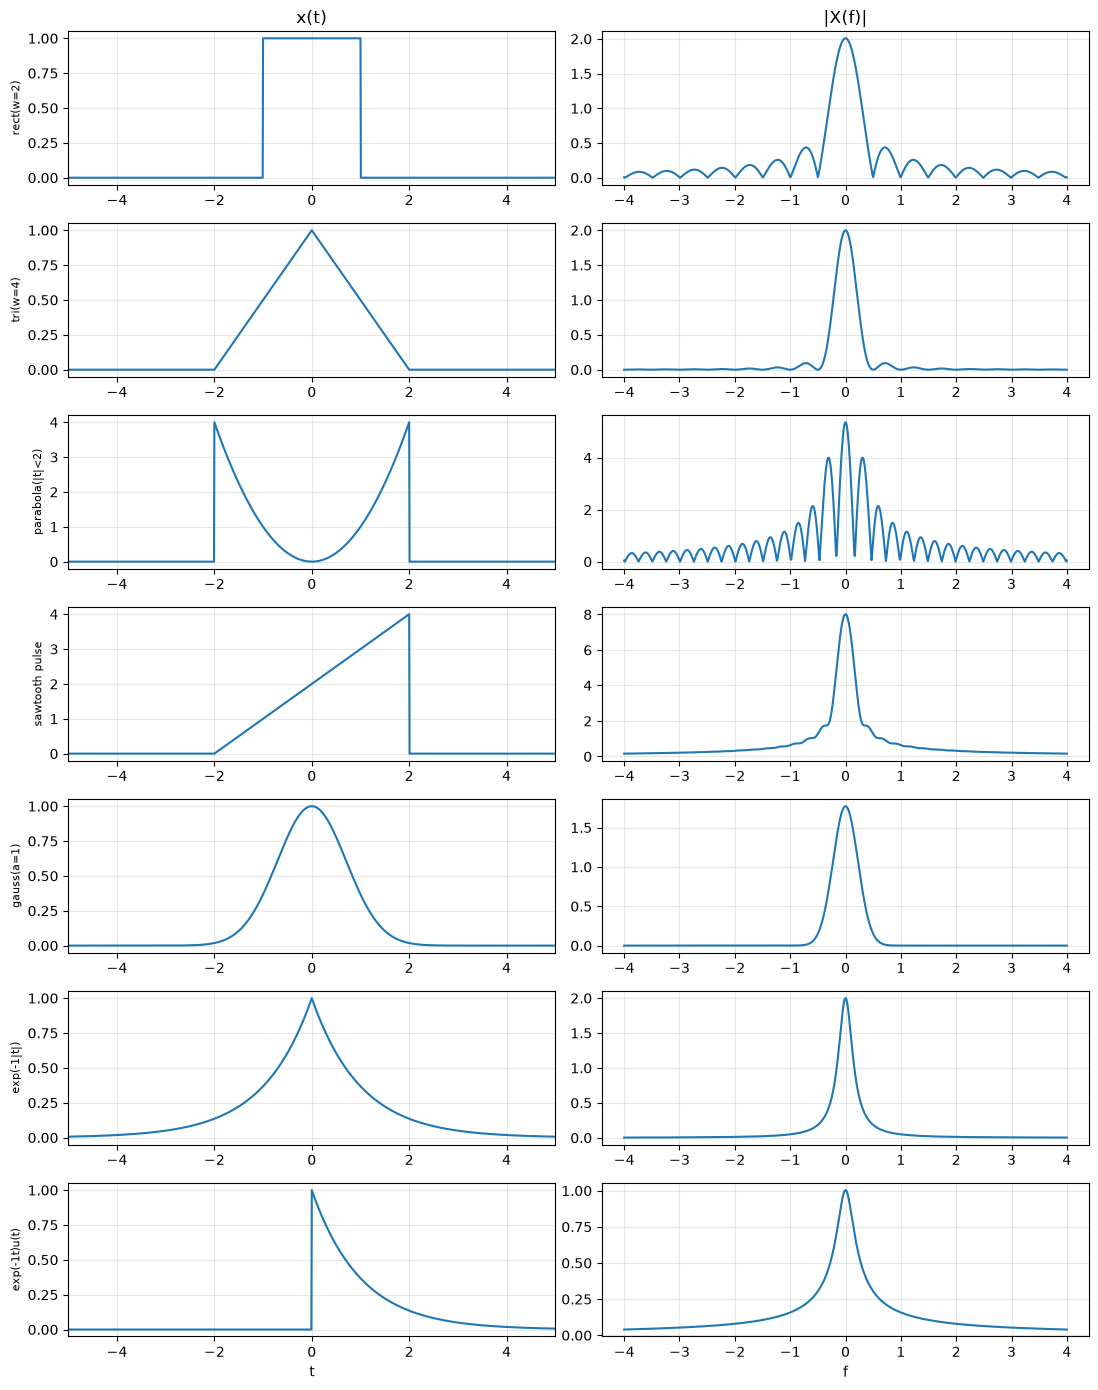

In [5]:
t = np.linspace(-8, 8, 2001)          # dt = 0.008  ->  Nyquist = 62.5 Hz
f = np.linspace(-4, 4, 801)
gen = SignalGenerator(t)

library = [gen.rect(2), gen.triangle(4), gen.parabola(2), gen.sawtooth_pulse(2),
           gen.gaussian(1), gen.two_sided_exp(1), gen.one_sided_exp(1)]

fig, axes = plt.subplots(len(library), 2, figsize=(11, 2.0 * len(library)))
for row, s in enumerate(library):
    X = CFTAnalyzer(s).transform(f)
    axes[row, 0].plot(t, s.values); axes[row, 0].set_xlim(-5, 5)
    axes[row, 0].set_ylabel(s.name, fontsize=8)
    axes[row, 1].plot(f, np.abs(X))
    if row == 0:
        axes[row, 0].set_title("x(t)"); axes[row, 1].set_title("|X(f)|")
axes[-1, 0].set_xlabel("t"); axes[-1, 1].set_xlabel("f")
plt.tight_layout(); plt.show()

In [6]:
# check two of them against the closed forms in the table
X_rect = CFTAnalyzer(gen.rect(2)).transform(f)
print("rect  vs  w*sinc(w f)   max err =",
      np.abs(X_rect - 2 * np.sinc(2 * f)).max(),
      "\n   (not machine precision: the trapezoid rule cannot resolve the jump at |t|=1)")

X_gauss = CFTAnalyzer(gen.gaussian(1)).transform(f)
print("gauss vs  sqrt(pi)exp(-pi^2 f^2)  max err =",
      np.abs(X_gauss - np.sqrt(np.pi) * np.exp(-np.pi ** 2 * f ** 2)).max())

rect  vs  w*sinc(w f)   max err = 0.008001016056317117 
   (not machine precision: the trapezoid rule cannot resolve the jump at |t|=1)


gauss vs  sqrt(pi)exp(-pi^2 f^2)  max err = 4.440892098500626e-16


---
## 3. Forward transform, inverse transform, and choosing the frequency range

The practice sheet asks: *"Try different frequency ranges... at some point higher
frequencies will distort the results. Why?"* Here is the answer, and it is worth
understanding because it explains a whole class of confusing results.

Your integral is evaluated on **sampled** data with spacing $dt$, so what you
actually compute is

$$X_{\text{num}}(f)\;\approx\;dt\sum_k x(t_k)e^{-j2\pi f t_k}$$

and that sum is **periodic in $f$ with period $1/dt$**. Past the Nyquist
frequency $1/(2dt)$ you are not seeing new information — you are seeing an
aliased copy of the spectrum you already had. Feeding those copies into the
inverse integral adds energy that was never in the signal.

So there are two failure modes, at opposite ends:

- **Range too narrow** — you truncate real content and the reconstruction is a
  smoothed, ringing version of the original (Gibbs).
- **Range past Nyquist** — you integrate aliased copies and the reconstruction
  degrades again.

The sweet spot is wide enough to contain the signal's real bandwidth, and never
beyond $1/(2dt)$.

dt = 0.01001 s   ->   Nyquist = 50.0 Hz


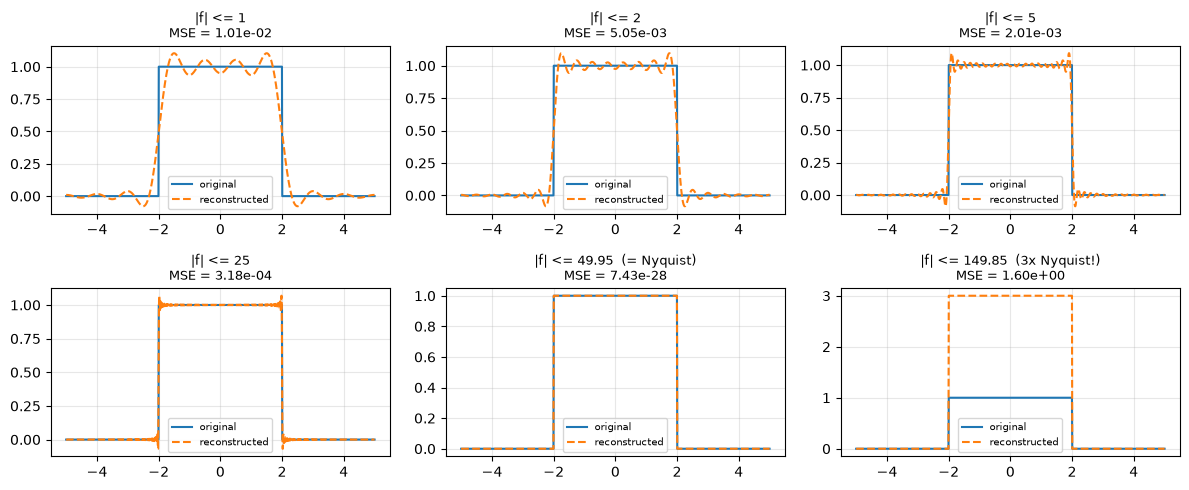

reconstruction MSE vs how wide the frequency axis is:
  |f| <=    1.0   MSE = 1.0084e-02
  |f| <=    2.0   MSE = 5.0519e-03
  |f| <=    5.0   MSE = 2.0088e-03
  |f| <=   25.0   MSE = 3.1806e-04
  |f| <=   50.0   MSE = 7.4296e-28  <- best: exactly Nyquist
  |f| <=  149.9   MSE = 1.6000e+00  <- worse again: aliased copies


In [7]:
# same setup as the practice sheet: rect on [-5,5] with 1000 samples
t3 = np.linspace(-5, 5, 1000)
dt = t3[1] - t3[0]
nyq = 1 / (2 * dt)
print(f"dt = {dt:.5f} s   ->   Nyquist = {nyq:.1f} Hz")

x3 = SignalGenerator(t3).rect(4)
ranges = [1, 2, 5, 25, nyq, 3 * nyq]

fig, axes = plt.subplots(2, 3, figsize=(12, 5))
scores = []
for ax, F in zip(axes.ravel(), ranges):
    fa = np.linspace(-F, F, 801)
    X = CFTAnalyzer(x3).transform(fa)
    rec = CFTAnalyzer.inverse(X, fa, t3).real
    err = np.mean((rec - x3.values) ** 2)
    scores.append((F, err))
    ax.plot(t3, x3.values, label="original")
    ax.plot(t3, rec, "--", label="reconstructed")
    tag = "  (= Nyquist)" if abs(F - nyq) < 1e-9 else ("  (3x Nyquist!)" if F > nyq else "")
    ax.set_title(f"|f| <= {F:g}{tag}\nMSE = {err:.2e}", fontsize=9)
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

print("reconstruction MSE vs how wide the frequency axis is:")
for F, err in scores:
    note = ("  <- best: exactly Nyquist" if abs(F - nyq) < 1e-9
            else "  <- worse again: aliased copies" if F > nyq else "")
    print(f"  |f| <= {F:6.1f}   MSE = {err:.4e}{note}")

Read the MSE numbers rather than the pictures: it falls as the band widens,
bottoms out around Nyquist, then **rises again** past it. That rise is the
aliased copies being integrated back in — exactly the effect that made
Parseval's theorem appear to fail by a factor of 2 in the 21B online when the
frequency axis was widened past Nyquist.

---
# 4. Fourier transform properties

Common setup for this whole section. The Gaussian is the default test signal
because it is smooth (so numerical derivatives behave) and decays fast (so
nothing is truncated by the window).

Each demo follows the same three lines the exams want:
build the modified signal **through the class**, transform it, compare against
the theoretical prediction with `verify(...)`.

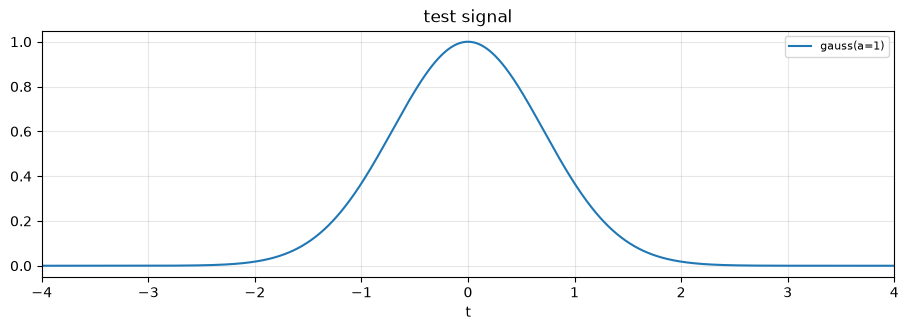

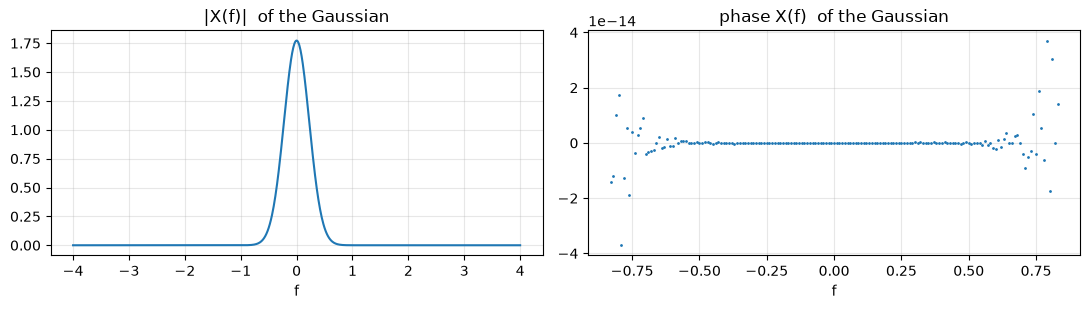

In [8]:
t = np.linspace(-8, 8, 2001)
f = np.linspace(-4, 4, 801)
gen = SignalGenerator(t)

x = gen.gaussian(1.0)                 # the default test signal
X = CFTAnalyzer(x).transform(f)
plot_signals([x], "test signal", xlim=(-4, 4))
plot_spectrum(f, X, "of the Gaussian")

## 4.1 Linearity

$$a\,x(t)+b\,y(t)\;\longleftrightarrow\;a\,X(f)+b\,Y(f)$$

The one property with no catch. It is what lets you break a complicated signal
into standard pieces, transform each, and add — which is exactly the 22C
strategy (`Square + Triangle`).

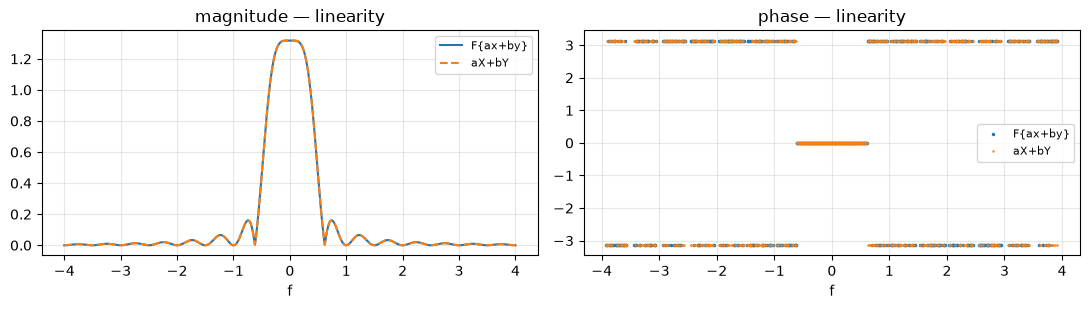

linearity
  magnitude MSE = 2.165e-32  (relative 1.301e-31)
  phase MSE     = 2.632e-28   [over 687 significant points]


In [9]:
y = gen.triangle(4)
a, b = 3.0, -2.0

lhs = CFTAnalyzer(a * x + b * y).transform(f)      # transform of the combination
rhs = a * X + b * CFTAnalyzer(y).transform(f)      # combination of the transforms
verify(f, lhs, rhs, "linearity", ("F{ax+by}", "aX+bY"));

## 4.2 Time shift

$$x(t-t_0)\;\longleftrightarrow\;X(f)\,e^{-j2\pi f t_0}$$

**Magnitude is unchanged; only phase moves,** picking up a linear ramp of slope
$-2\pi t_0$. Delaying a signal cannot change how much of each frequency it
contains, only when they line up. This was the whole of online 22B.

**Gotcha.** Comparing $\angle Y$ against $\angle X - 2\pi f t_0$ directly gives
a huge MSE, because `np.angle` folds its output into $(-\pi,\pi]$ while the
arithmetic ramp keeps growing. The difference comes out as exact multiples of
$2\pi$. Always `wrap()` the difference — that is what `verify` does internally.

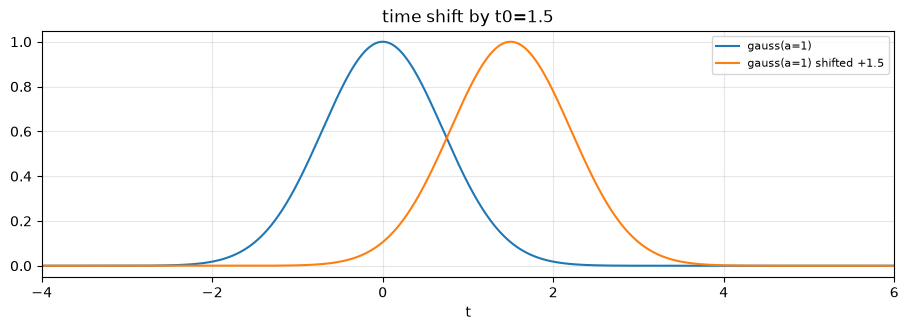

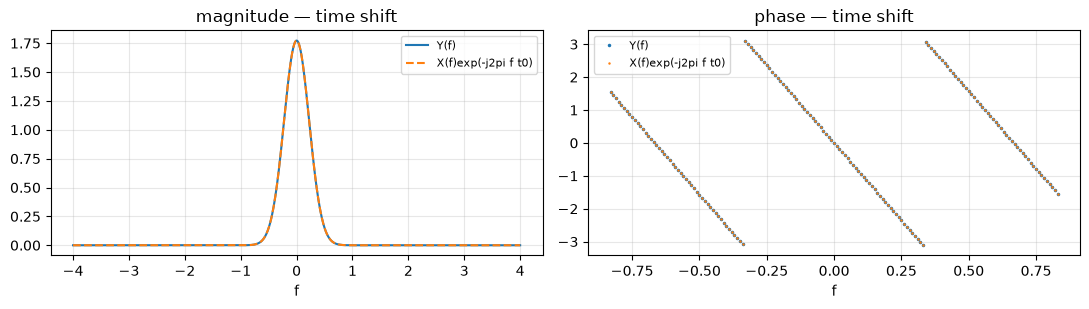

time shift
  magnitude MSE = 1.587e-32  (relative 1.015e-31)
  phase MSE     = 9.550e-29   [over 167 significant points]

  raw                  : 4.791e+02   <- 2pi lap-counting dominates
  after wrap()         : 1.575e+00   <- better, but still polluted
  after wrap() + mask  : 9.514e-29   <- the real answer

  the middle number is not the property failing: it averages in the phase of
  numerical noise at frequencies where |X(f)| is essentially zero.


In [10]:
t0 = 1.5
y = x.time_shift(t0)
Y = CFTAnalyzer(y).transform(f)
pred = X * np.exp(-2j * np.pi * f * t0)

plot_signals([x, y], f"time shift by t0={t0}", xlim=(-4, 6))
verify(f, Y, pred, "time shift", ("Y(f)", "X(f)exp(-j2pi f t0)"));

# the two corrections, applied one at a time
d = np.angle(Y) - (np.angle(X) - 2 * np.pi * f * t0)
m = significant(X)
print(f"\n  raw                  : {np.mean(d**2):.3e}   <- 2pi lap-counting dominates")
print(f"  after wrap()         : {np.mean(wrap(d)**2):.3e}   <- better, but still polluted")
print(f"  after wrap() + mask  : {np.mean(wrap(d)[m]**2):.3e}   <- the real answer")
print("\n  the middle number is not the property failing: it averages in the phase of")
print("  numerical noise at frequencies where |X(f)| is essentially zero.")

## 4.3 Frequency shift (modulation)

$$x(t)\,e^{+j2\pi f_0 t}\;\longleftrightarrow\;X(f-f_0)$$

The mirror image of the time shift: multiplying by a complex exponential in time
**translates the spectrum** without deforming it. For real signals you would use
$\cos(2\pi f_0t)$ instead, which by Euler splits the spectrum into two half-height
copies at $\pm f_0$ — that is amplitude modulation, and it is why multiplying two
sinusoids creates sum and difference frequencies (the 21C problem).

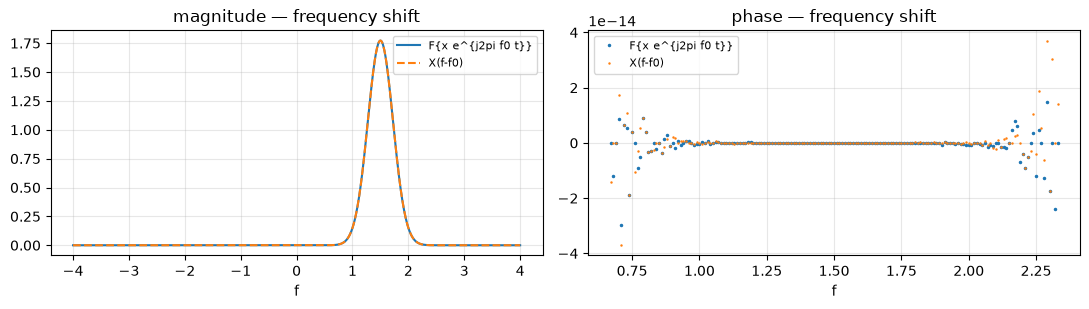

frequency shift
  magnitude MSE = 3.742e-33  (relative 2.391e-32)
  phase MSE     = 2.135e-29   [over 167 significant points]


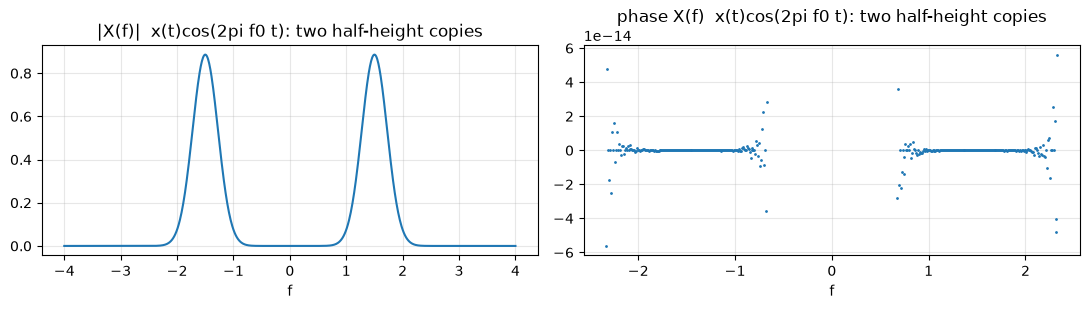

In [11]:
f0 = 1.5
y = x.modulate(f0)
Y = CFTAnalyzer(y).transform(f)
pred = CFTAnalyzer(x).transform(f - f0)           # X evaluated at (f - f0)
verify(f, Y, pred, "frequency shift", ("F{x e^{j2pi f0 t}}", "X(f-f0)"));

# the real-signal version: multiplying by cos(2*pi*f0*t) gives two half copies
y_cos = x * gen.cosine(1.0, f0)
plot_spectrum(f, CFTAnalyzer(y_cos).transform(f), "x(t)cos(2pi f0 t): two half-height copies")

## 4.4 Time scaling

$$x(at)\;\longleftrightarrow\;\frac{1}{|a|}X\!\left(\frac{f}{a}\right)$$

Compress in time, stretch in frequency, and shrink the height by $|a|$ — the
signal cannot be brief *and* narrowband. Note both effects: many students get the
stretch and forget the $1/|a|$.

**Gotcha.** This holds exactly only if the whole signal still fits in your time
window after scaling. Stretching ($|a|<1$) pushes energy out of the window and
the property will appear to fail — the fault is the window, not the theory.

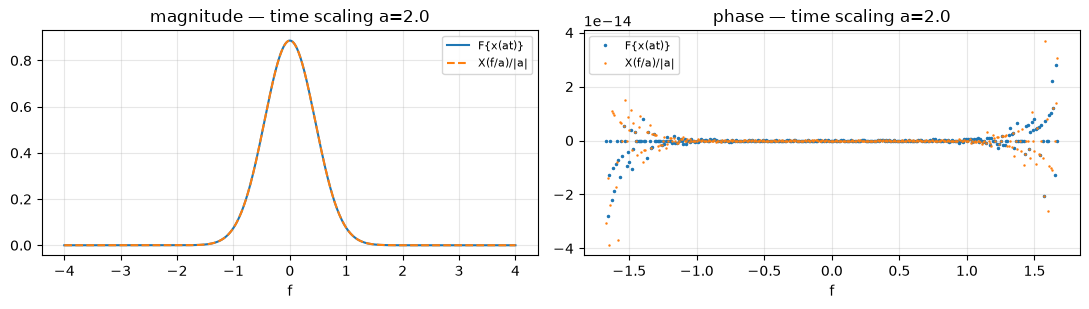

time scaling a=2.0
  magnitude MSE = 2.266e-33  (relative 2.897e-32)
  phase MSE     = 4.032e-29   [over 335 significant points]


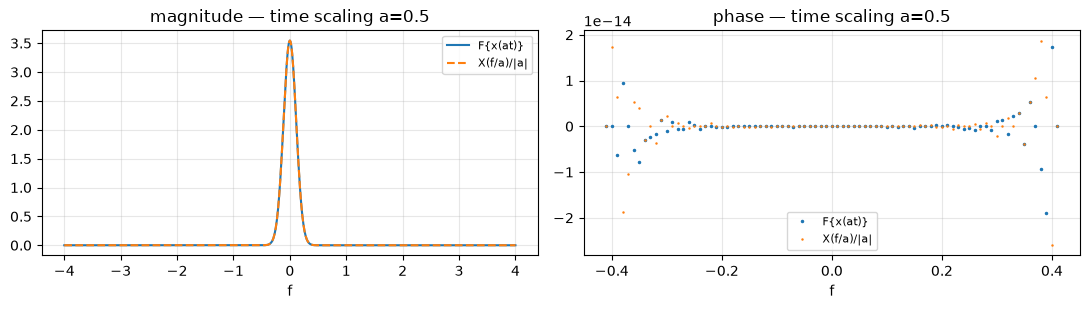

time scaling a=0.5
  magnitude MSE = 3.463e-16  (relative 1.107e-15)
  phase MSE     = 6.154e-29   [over 83 significant points]


In [12]:
for a in (2.0, 0.5):
    y = x.time_scale(a)
    Y = CFTAnalyzer(y).transform(f)
    pred = CFTAnalyzer(x).transform(f / a) / abs(a)
    verify(f, Y, pred, f"time scaling a={a}", ("F{x(at)}", "X(f/a)/|a|"))

## 4.5 Time reversal

$$x(-t)\;\longleftrightarrow\;X(-f)$$

The $a=-1$ case of scaling. For a **real** signal $X(-f)=\overline{X(f)}$, so
reversing time conjugates the spectrum: identical magnitude, negated phase.

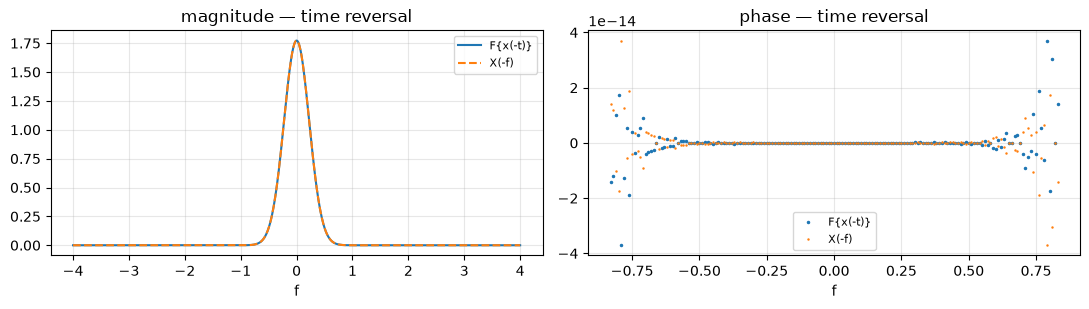

time reversal
  magnitude MSE = 0.000e+00  (relative 0.000e+00)
  phase MSE     = 1.532e-28   [over 167 significant points]

  X(-f) == conj(X(f)) for real x?  max err = 0.0


In [13]:
y = x.time_reverse()
Y = CFTAnalyzer(y).transform(f)
pred = CFTAnalyzer(x).transform(-f)
verify(f, Y, pred, "time reversal", ("F{x(-t)}", "X(-f)"))

# for real x this is the same as conjugating
print("\n  X(-f) == conj(X(f)) for real x?  max err =",
      np.abs(CFTAnalyzer(x).transform(-f) - np.conj(X)).max())

## 4.6 Conjugation and symmetry

For a **real** signal the spectrum is *Hermitian*: $X(-f)=\overline{X(f)}$, so
$|X|$ is even and $\angle X$ is odd. Two useful specialisations:

| $x(t)$ | $X(f)$ |
|---|---|
| real and **even** | real and even (phase 0 or $\pi$) |
| real and **odd** | purely **imaginary** and odd |

That second row is why the 21C coefficients came out purely imaginary — the
signal was a sum of sines, which is odd. Seeing an all-imaginary spectrum is a
sign your signal is odd, not a sign something broke.

even signal: max |imag(X)| = 1.39e-16  -> X is real
odd  signal: max |real(X)| = 1.16e-16  -> X is imaginary


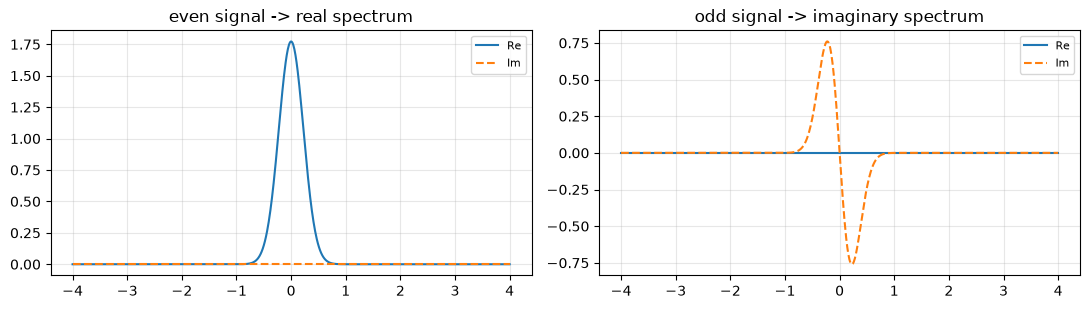

In [14]:
even = gen.gaussian(1.0)                       # real and even
odd = Signal(t, lambda u: u * np.exp(-u ** 2), "t*exp(-t^2)")   # real and odd

E, O = CFTAnalyzer(even).transform(f), CFTAnalyzer(odd).transform(f)
print(f"even signal: max |imag(X)| = {np.abs(E.imag).max():.2e}  -> X is real")
print(f"odd  signal: max |real(X)| = {np.abs(O.real).max():.2e}  -> X is imaginary")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(f, E.real, label="Re"); ax[0].plot(f, E.imag, "--", label="Im")
ax[0].set_title("even signal -> real spectrum"); ax[0].legend(fontsize=8)
ax[1].plot(f, O.real, label="Re"); ax[1].plot(f, O.imag, "--", label="Im")
ax[1].set_title("odd signal -> imaginary spectrum"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4.7 Differentiation in time

$$\frac{d^n x}{dt^n}\;\longleftrightarrow\;(j2\pi f)^n\,X(f)$$

Differentiating **amplifies high frequencies** (multiplies by $|2\pi f|^n$) and
adds a $90°$ phase per order. This was online 22A.

**Gotchas.** (1) The $n$-th derivative scales the spectrum by $(2\pi f)^n$, so
the raw MSE grows by orders of magnitude with $n$ even when accuracy is
unchanged — quote the *relative* error. (2) Differentiating a signal with a jump
is numerically hopeless; use smooth signals, or derive the derivative by hand as
22A does.

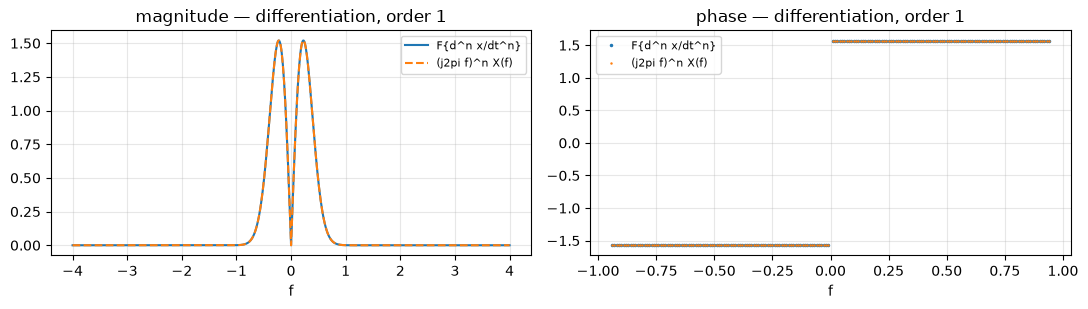

differentiation, order 1
  magnitude MSE = 2.670e-10  (relative 1.707e-09)
  phase MSE     = 7.450e-28   [over 188 significant points]


differentiation, order 2
  magnitude MSE = 7.476e-09  (relative 1.593e-08)
  phase MSE     = 4.388e-26   [over 202 significant points]
differentiation, order 3
  magnitude MSE = 1.514e-07  (relative 6.449e-08)
  phase MSE     = 4.274e-25   [over 210 significant points]


In [15]:
for n in (1, 2, 3):
    dn = x
    for _ in range(n):
        dn = dn.derivative()
    Y = CFTAnalyzer(dn).transform(f)
    pred = (2j * np.pi * f) ** n * X
    verify(f, Y, pred, f"differentiation, order {n}",
           ("F{d^n x/dt^n}", "(j2pi f)^n X(f)"), plot=(n == 1))

## 4.8 Multiplication by $t$ (differentiation in frequency)

$$t\,x(t)\;\longleftrightarrow\;\frac{j}{2\pi}\,\frac{dX}{df}$$

The dual of 4.7: multiplying by $t$ in one domain differentiates in the other.
Derivation is one line — differentiate $X(f)=\int x e^{-j2\pi ft}dt$ under the
integral sign and a factor $-j2\pi t$ falls out.

Repeating it $n$ times gives $t^n x(t) \leftrightarrow (j/2\pi)^n X^{(n)}(f)$,
which is how you would handle a question about $t^2x(t)$.

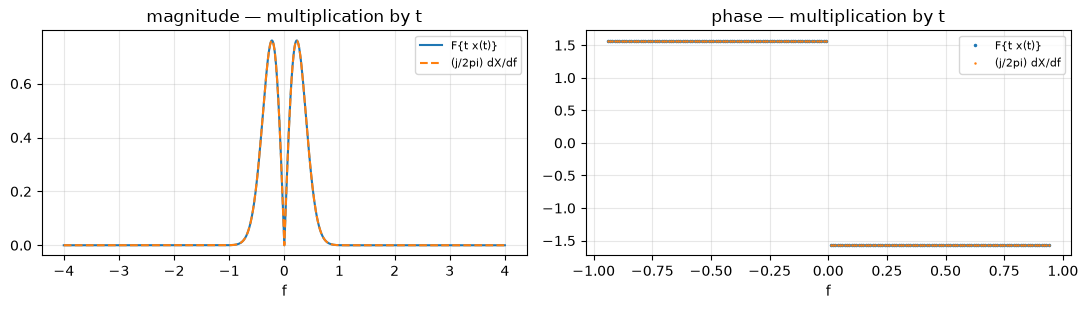

multiplication by t
  magnitude MSE = 1.587e-08  (relative 4.060e-07)
  phase MSE     = 8.606e-27   [over 188 significant points]


In [16]:
y = x.multiply_by_t()
Y = CFTAnalyzer(y).transform(f)
pred = (1j / (2 * np.pi)) * np.gradient(X, f)     # numerical dX/df
verify(f, Y, pred, "multiplication by t", ("F{t x(t)}", "(j/2pi) dX/df"));

## 4.9 Integration

$$\int_{-\infty}^{t}x(\tau)\,d\tau\;\longleftrightarrow\;\frac{X(f)}{j2\pi f}\;+\;\frac{X(0)}{2}\,\delta(f)$$

Integration **suppresses** high frequencies ($1/f$) — the opposite of
differentiation, and the reason integrating is a smoothing operation.

**Gotcha.** That $\delta(f)$ term appears whenever $X(0)=\int x\,dt \neq 0$, and
a delta cannot be represented on a numerical grid. Demonstrate with a
**zero-mean** signal so the term vanishes; here the odd signal $t\,e^{-t^2}$
integrates to a Gaussian.

X(0) = 0.00e+00+0.00e+00j  -> no delta term


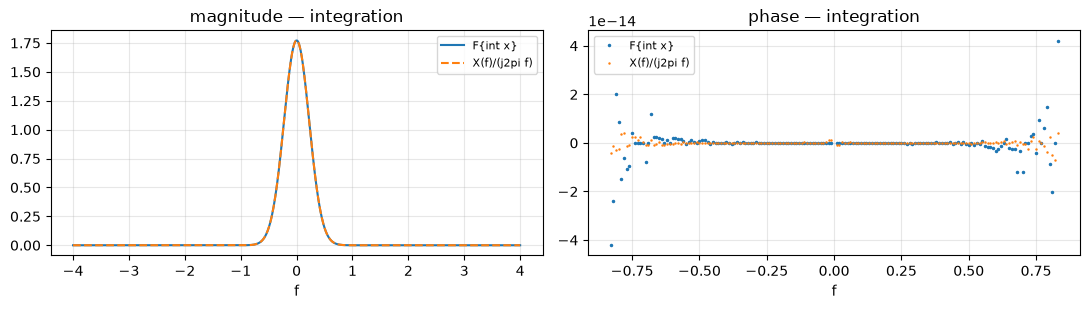

integration
  magnitude MSE = 1.337e-11  (relative 8.753e-11)
  phase MSE     = 3.750e-29   [over 166 significant points]


In [17]:
odd = Signal(t, lambda u: -2 * u * np.exp(-u ** 2), "-2t exp(-t^2)")
O = CFTAnalyzer(odd).transform(f)
print(f"X(0) = {CFTAnalyzer(odd).transform([0.0])[0]:.2e}  -> no delta term")

y = odd.integral()
Y = CFTAnalyzer(y).transform(f)
nz = np.abs(f) > 1e-9                              # skip f = 0
verify(f[nz], Y[nz], O[nz] / (2j * np.pi * f[nz]), "integration",
       ("F{int x}", "X(f)/(j2pi f)"));

## 4.10 Convolution theorem

$$x(t)*y(t)\;\longleftrightarrow\;X(f)\,Y(f)$$

The most useful property in the course: **convolution is expensive, multiplication
is cheap.** Every filter in Section 6 is this theorem — instead of sliding a
kernel over an image, multiply the two spectra.

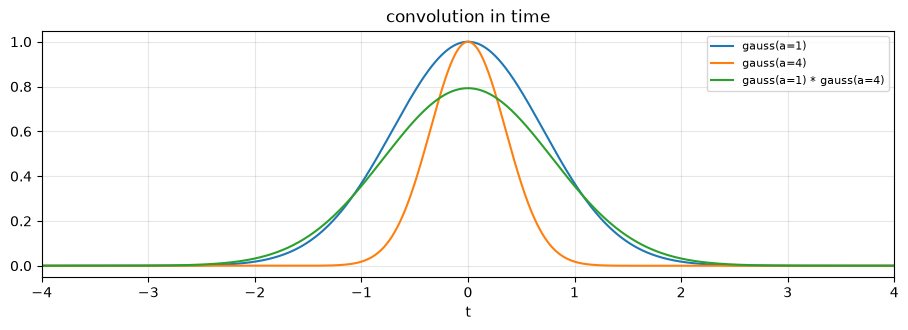

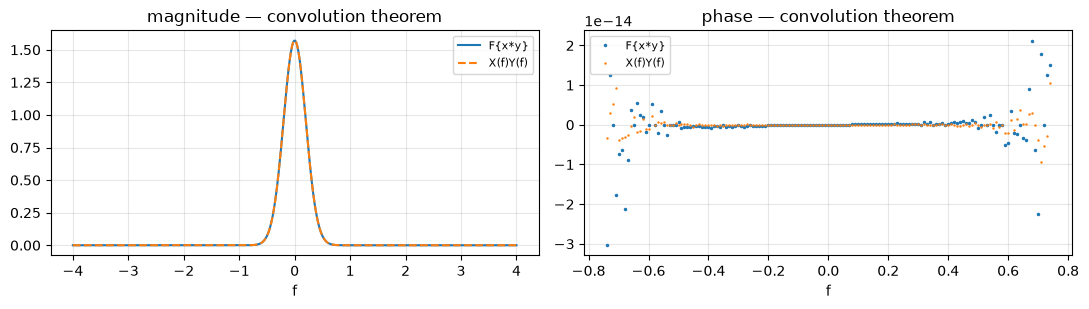

convolution theorem
  magnitude MSE = 1.187e-31  (relative 1.080e-30)
  phase MSE     = 2.670e-29   [over 149 significant points]


In [18]:
g1, g2 = gen.gaussian(1.0), gen.gaussian(4.0)
conv = g1.convolve(g2)

lhs = CFTAnalyzer(conv).transform(f)
rhs = CFTAnalyzer(g1).transform(f) * CFTAnalyzer(g2).transform(f)

plot_signals([g1, g2, conv], "convolution in time", xlim=(-4, 4))
verify(f, lhs, rhs, "convolution theorem", ("F{x*y}", "X(f)Y(f)"));

## 4.11 Multiplication theorem

$$x(t)\,y(t)\;\longleftrightarrow\;X(f)*Y(f)$$

The same statement read backwards. It explains **windowing**: cutting a signal
off with a rect multiplies in time, so it *convolves* the spectrum with a sinc —
which is precisely the spectral leakage that smeared the noise frequency across
two harmonics in the 21A image problem.

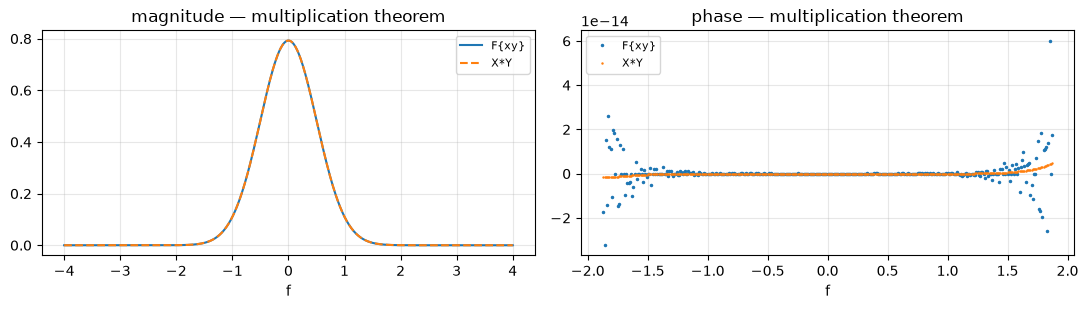

multiplication theorem
  magnitude MSE = 3.189e-29  (relative 4.557e-28)
  phase MSE     = 3.167e-29   [over 375 significant points]

  Try this with a windowed cosine instead and the check degrades near the
  edges of the f-axis: that spectrum is a pair of sincs whose 1/f tails get
  truncated. The degradation IS the leakage this property predicts.


In [19]:
# two Gaussians: both spectra are compact, so the numerical convolution on a
# finite f-axis is not truncated and the check is clean
p, q = gen.gaussian(1.0), gen.gaussian(4.0)

lhs = CFTAnalyzer(p * q).transform(f)
P, Q = CFTAnalyzer(p).transform(f), CFTAnalyzer(q).transform(f)
df = f[1] - f[0]
rhs = np.convolve(P, Q, mode="same") * df          # convolution on the f grid

verify(f, lhs, rhs, "multiplication theorem", ("F{xy}", "X*Y"))
print("\n  Try this with a windowed cosine instead and the check degrades near the")
print("  edges of the f-axis: that spectrum is a pair of sincs whose 1/f tails get")
print("  truncated. The degradation IS the leakage this property predicts.")

## 4.12 Parseval / Rayleigh — energy

$$\int_{-\infty}^{\infty}|x(t)|^2dt=\int_{-\infty}^{\infty}|X(f)|^2df$$

Energy is the same whichever domain you count it in. This was online 21B.

**Gotcha.** The frequency integral must stay **inside Nyquist**. Widening the
axis past $1/(2dt)$ integrates aliased copies and inflates the right-hand side by
an integer factor — the table below shows it doubling, then quadrupling.

In [20]:
x21b = SignalGenerator(np.linspace(-10, 10, 1001)).piecewise_21b()
t21, dt21 = x21b.t, x21b.t[1] - x21b.t[0]
E_time = np.trapezoid(np.abs(x21b.values) ** 2, t21)
print(f"Nyquist = {1/(2*dt21):.1f} Hz\n  time-domain energy = {E_time:.6f}\n")

for F in (10, 20, 50, 100):
    fa = np.linspace(-F, F, 2001)
    Xa = CFTAnalyzer(x21b).transform(fa)
    E_freq = np.trapezoid(np.abs(Xa) ** 2, fa)
    flag = "" if F < 1 / (2 * dt21) else "   <- past Nyquist, aliased"
    print(f"  |f| <= {F:3d}: freq energy = {E_freq:10.6f}   "
          f"rel err = {abs(E_time-E_freq)/E_time:.2e}{flag}")

Nyquist = 25.0 Hz
  time-domain energy = 53.468933



  |f| <=  10: freq energy =  53.468918   rel err = 2.95e-07


  |f| <=  20: freq energy =  53.468931   rel err = 4.41e-08


  |f| <=  50: freq energy = 106.937867   rel err = 1.00e+00   <- past Nyquist, aliased


  |f| <= 100: freq energy = 213.875733   rel err = 3.00e+00   <- past Nyquist, aliased


## 4.13 Duality

$$\text{if}\quad x(t)\leftrightarrow X(f)\qquad\text{then}\qquad X(t)\leftrightarrow x(-f)$$

Take a transform's *shape* and feed it back in as a time signal: you recover the
original, mirrored. This is why rect $\leftrightarrow$ sinc works in both
directions, and it doubles the size of any table of pairs you have memorised.

**Gotcha.** A sinc decays only as $1/t$, so any finite window truncates it badly.
Expect visible ripple in the recovered rect — that ripple is the window, not an
error in the property.

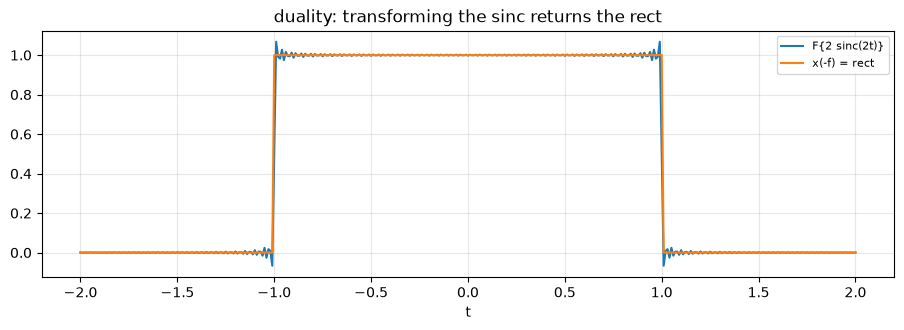

max error overall        = 0.5006
max error away from jump = 0.0257   <- the ripple, from the truncated 1/t tail
value at the jump f=1    = 0.4994
   a Fourier integral converges to the MIDPOINT of a jump, so 0.5 here is
   correct, not an error -- the 'max error overall' is that one point.


In [21]:
t_wide = np.linspace(-40, 40, 4001)                # sinc needs a long window
gw = SignalGenerator(t_wide)
f_d = np.linspace(-2, 2, 401)

rect = gw.rect(2)                                   # x(t) = rect, X(f) = 2sinc(2f)
sinc_as_time = gw.sinc_pulse(1.0)                   # now feed X's shape in as time

D = CFTAnalyzer(sinc_as_time).transform(f_d)
target = rect.func(-f_d)
plot_signals([(f_d, D.real, "F{2 sinc(2t)}"), (f_d, target, "x(-f) = rect")],
             "duality: transforming the sinc returns the rect")

err = np.abs(D.real - target)
away = np.abs(np.abs(f_d) - 1) > 0.05                  # exclude the jump itself
print(f"max error overall        = {err.max():.4f}")
print(f"max error away from jump = {err[away].max():.4f}   <- the ripple, from the truncated 1/t tail")
print(f"value at the jump f=1    = {D.real[np.argmin(np.abs(f_d - 1))]:.4f}")
print("   a Fourier integral converges to the MIDPOINT of a jump, so 0.5 here is")
print("   correct, not an error -- the 'max error overall' is that one point.")

## 4.14 Putting two together (the 22C pattern)

Exams like to **compose** properties. Scaling then modulating gives

$$y(t)=x(at)\,e^{j2\pi f_0t}\;\longleftrightarrow\;\frac{1}{|a|}X\!\left(\frac{f-f_0}{a}\right)$$

**Order matters.** Scale first then modulate and the spectrum lands at $f_0$;
modulate first then scale and it lands at $a f_0$. Read the question carefully.

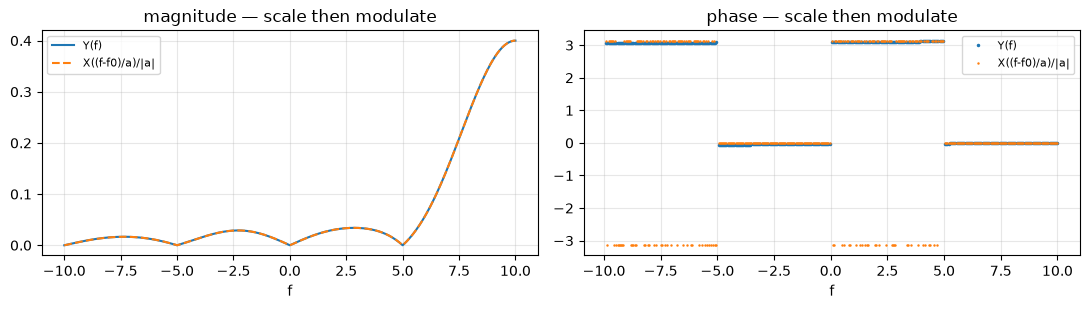

scale then modulate
  magnitude MSE = 7.960e-09  (relative 5.015e-07)
  phase MSE     = 2.176e-03   [over 396 significant points]


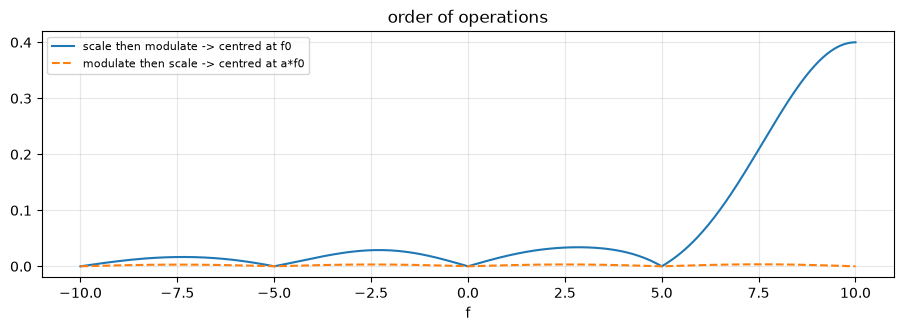

In [22]:
t_c = np.linspace(-5, 5, 8001)
gc = SignalGenerator(t_c)
xc = gc.rect(2) + gc.triangle(4)
a, f0 = 10.0, 10.0
fc = np.linspace(-10, 10, 401)

y = xc.time_scale(a).modulate(f0)                  # scale, THEN modulate
Y = CFTAnalyzer(y).transform(fc)
pred = CFTAnalyzer(xc).transform((fc - f0) / a) / abs(a)
verify(fc, Y, pred, "scale then modulate", ("Y(f)", "X((f-f0)/a)/|a|"))

# the other order lands somewhere else entirely
Y2 = CFTAnalyzer(xc.modulate(f0).time_scale(a)).transform(fc)
plt.figure(); plt.plot(fc, np.abs(Y), label="scale then modulate -> centred at f0")
plt.plot(fc, np.abs(Y2), "--", label="modulate then scale -> centred at a*f0")
plt.legend(fontsize=8); plt.xlabel("f"); plt.title("order of operations"); plt.show()

---
# 5. Fourier series properties

**When to use which.** A Fourier *series* is for **periodic** signals and gives a
discrete set of coefficients $c_n$. A Fourier *transform* is for **aperiodic**
(finite-energy) signals and gives a continuous $X(f)$. Applying the CFT to a
periodic signal does not converge — the true answer is a train of impulses, and
numerically you get tall narrow spikes whose height depends on your window
length, which is meaningless.

$$c_n=\frac{1}{T}\int_T x(t)e^{-jn\omega_0 t}dt
\qquad
x(t)=\sum_{n=-\infty}^{\infty}c_n e^{jn\omega_0 t},\qquad \omega_0=\frac{2\pi}{T}$$

**Reading a real signal off the coefficients.** Harmonic $n$ sits at frequency
$n/T$ Hz with

$$\text{amplitude}=2|c_n|,\qquad
\text{phase (sine convention)}=\angle c_n+\tfrac{\pi}{2}$$

The **2** is there because a real sinusoid is split across the conjugate pair
$c_n$ and $c_{-n}$, each carrying half. The $\pi/2$ converts the cosine that the
pair naturally sums to into a sine, via $\cos x=\sin(x+\pi/2)$. Drop either and
your numbers look wrong while your maths is right.

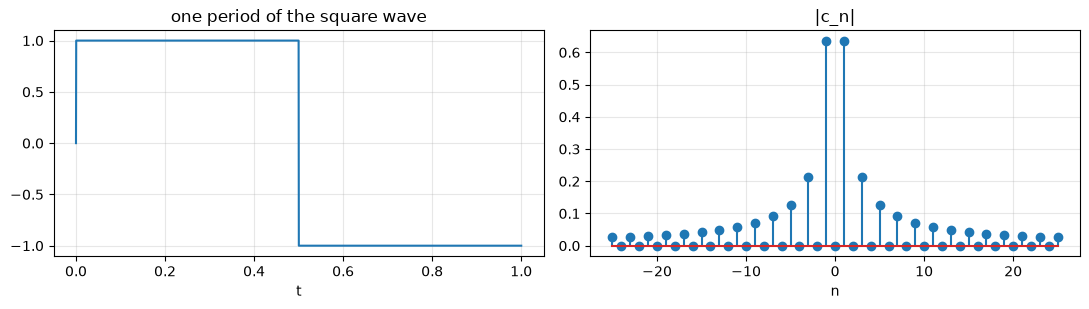

only odd harmonics survive (the square wave is odd and half-wave symmetric):
   [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]


In [23]:
# one period of a square wave, and its coefficients
T = 1.0
t_p = np.linspace(0, T, 2001)
gp = SignalGenerator(t_p)
sq = gp.square_wave(T)

fs = FourierSeries(t_p, sq.values, n_harmonics=25, T=T)
c = fs.compute()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(t_p, sq.values); ax[0].set_title("one period of the square wave"); ax[0].set_xlabel("t")
ax[1].stem(fs.n, np.abs(c)); ax[1].set_title("|c_n|"); ax[1].set_xlabel("n")
plt.tight_layout(); plt.show()

print("only odd harmonics survive (the square wave is odd and half-wave symmetric):")
print("  ", [int(n) for n in fs.n if abs(c[np.where(fs.n == n)[0][0]]) > 1e-3 and n > 0])

## 5.1 Reconstruction and the Gibbs phenomenon

Truncating the series at $N$ harmonics never removes the overshoot at a jump —
it is about **9%** of the jump height no matter how large $N$ gets. The
overshoot only gets *narrower*. Worth knowing so you do not chase it as a bug.

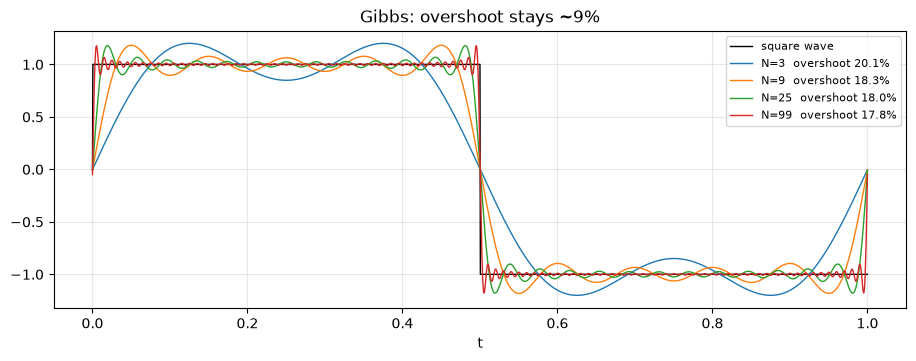

In [24]:
plt.figure(figsize=(11, 3.6))
plt.plot(t_p, sq.values, "k", lw=1, label="square wave")
for N in (3, 9, 25, 99):
    fsN = FourierSeries(t_p, sq.values, N, T=T); fsN.compute()
    rec = fsN.reconstruct(t_p).real
    over = (rec.max() - 1) * 100
    plt.plot(t_p, rec, lw=1, label=f"N={N}  overshoot {over:.1f}%")
plt.legend(fontsize=8); plt.xlabel("t"); plt.title("Gibbs: overshoot stays ~9%"); plt.show()

## 5.2 Identifying the components of a signal (the 21C workflow)

Given a messy expression, find which pure sinusoids it is made of. The recipe:
pick the time axis to span **exactly one period**, take the coefficients, and
read off every harmonic whose $|c_n|$ is above a threshold.

The test signal is the 21C one,
$f(t)=2\sin(14\pi t)-\sin(2\pi t)\,(4\sin(2\pi t)\sin(14\pi t)-1)$,
which simplifies by trigonometry to $\sin(18\pi t)+\sin(10\pi t)+\sin(2\pi t)$
— i.e. 9, 5 and 1 Hz. The fundamental is $\gcd(1,5,9)=1$ Hz, so $T=1$.

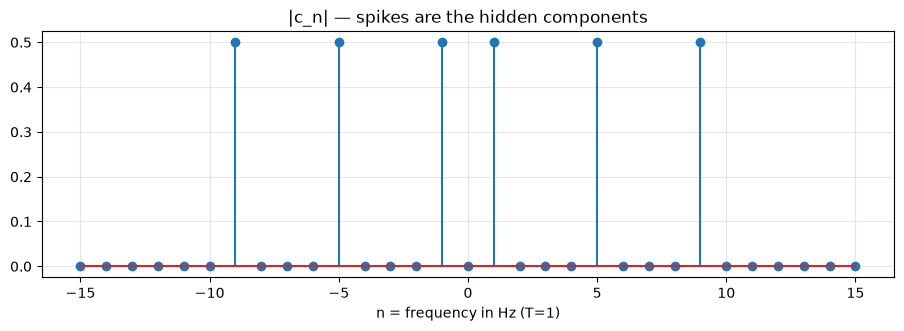

components found:
    1.0 Hz   amplitude 1.0000   phase +0.0000 rad
    5.0 Hz   amplitude 1.0000   phase +0.0000 rad
    9.0 Hz   amplitude 1.0000   phase +0.0000 rad

MSE of the rebuilt sum = 2.834e-30


In [25]:
t_c = np.linspace(0, 1, 2001)
A, B = np.sin(14 * np.pi * t_c), np.sin(2 * np.pi * t_c)
mystery = 2 * A - B * (4 * A * B - 1)

fsc = FourierSeries(t_c, mystery, n_harmonics=15, T=1.0)
fsc.compute()

plt.figure(); plt.stem(fsc.n, np.abs(fsc.coeffs))
plt.title("|c_n| — spikes are the hidden components"); plt.xlabel("n = frequency in Hz (T=1)")
plt.show()

print("components found:")
for freq, amp, ph in fsc.components(tol=1e-3):
    print(f"  {freq:5.1f} Hz   amplitude {amp:.4f}   phase {ph:+.4f} rad")

rebuilt = sum(np.sin(2 * np.pi * fr * t_c) for fr, _, _ in fsc.components())
print(f"\nMSE of the rebuilt sum = {np.mean((rebuilt - mystery)**2):.3e}")

## 5.3 Linearity, time shift, time reversal

$$a\,x+b\,y\;\to\;a\,c_n+b\,d_n \qquad
x(t-t_0)\;\to\;c_n e^{-jn\omega_0t_0} \qquad
x(-t)\;\to\;c_{-n}$$

Same shapes as the transform versions. Note the shift multiplies each harmonic
by its **own** phase factor — harmonic $n$ rotates $n$ times as fast, which is
what keeps the waveform rigid as it slides.

In [26]:
def coeffs_of(values, N=12, T=1.0, t=t_p):
    fsx = FourierSeries(t, values, N, T=T); return fsx.compute(), fsx

x_p = (gp.cosine(1.0, 1.0) + gp.sine(0.5, 3.0))     # 1 Hz + 3 Hz, one period
cx, fx = coeffs_of(x_p.values)
n, w0 = fx.n, fx.w0

# linearity
y_p = gp.square_wave(T)
cy, _ = coeffs_of(y_p.values)
c_lin, _ = coeffs_of((2 * x_p - 3 * y_p).values)
print("linearity      max err =", np.abs(c_lin - (2 * cx - 3 * cy)).max())

# time shift
t0 = 0.2
c_sh, _ = coeffs_of(x_p.time_shift(t0).values)
print("time shift     max err =", np.abs(c_sh - cx * np.exp(-1j * n * w0 * t0)).max())

# time reversal
c_rev, _ = coeffs_of(x_p.time_reverse().values)
print("time reversal  max err =", np.abs(c_rev - cx[::-1]).max())

linearity      max err = 4.965068306494546e-16
time shift     max err = 1.609494470028892e-16
time reversal  max err = 8.617163567189819e-17


## 5.4 Time scaling — the coefficients do **not** change

$$x(at)\ \text{has period}\ T/a,\ \text{and the same}\ c_n$$

This one surprises people. Compressing a periodic signal does not redistribute
energy between harmonics — harmonic $n$ is still harmonic $n$, it just sits at a
higher frequency because $\omega_0$ itself scaled. Contrast with the *transform*
(4.4), where scaling genuinely reshapes and rescales $X(f)$ by $1/|a|$.

In [27]:
a = 2.0
t_a = np.linspace(0, T / a, 2001)                   # ONE period of the scaled signal
x_scaled = Signal(t_a, x_p.func, "x(at)").time_scale(a)

fs_a = FourierSeries(t_a, x_scaled.values, 12, T=T / a); c_a = fs_a.compute()
print("max |c_n(scaled) - c_n(original)| =", np.abs(c_a - cx).max())
print(f"fundamental went from {1/T:.1f} Hz to {1/(T/a):.1f} Hz, coefficients unchanged")

max |c_n(scaled) - c_n(original)| = 0.0
fundamental went from 1.0 Hz to 2.0 Hz, coefficients unchanged


## 5.5 Differentiation, symmetry, and Parseval

$$\frac{dx}{dt}\;\to\;jn\omega_0c_n
\qquad
x\ \text{real}\;\Rightarrow\;c_{-n}=\overline{c_n}
\qquad
\frac{1}{T}\int_T|x|^2dt=\sum_n|c_n|^2$$

The series form of Parseval is a **sum**, not an integral — and unlike the
transform version there is no Nyquist trap, only truncation at $\pm N$.

In [28]:
# differentiation
c_d, _ = coeffs_of(x_p.derivative().values)
print("differentiation  max err =", np.abs(c_d - 1j * n * w0 * cx).max())

# conjugate symmetry of a real signal
print("conj symmetry    max err =", np.abs(cx[::-1] - np.conj(cx)).max())

# Parseval, as N grows
lhs = np.trapezoid(np.abs(x_p.values) ** 2, t_p) / T
print(f"\n(1/T) int |x|^2 dt = {lhs:.8f}")
for N in (1, 3, 12, 40):
    cN, _ = coeffs_of(x_p.values, N=N)
    print(f"  sum |c_n|^2 up to N={N:2d}: {np.sum(np.abs(cN)**2):.8f}")

differentiation  max err = 6.976381268675169e-05
conj symmetry    max err = 0.0

(1/T) int |x|^2 dt = 0.62500000
  sum |c_n|^2 up to N= 1: 0.50000000
  sum |c_n|^2 up to N= 3: 0.62500000
  sum |c_n|^2 up to N=12: 0.62500000
  sum |c_n|^2 up to N=40: 0.62500000


## 5.6 Multiplication and periodic convolution

$$x(t)\,y(t)\;\to\;\sum_k c_k\,d_{n-k}\quad(\text{convolution of the coefficient
sequences})$$

$$\big(x\circledast y\big)(t)=\int_T x(\tau)y(t-\tau)d\tau\;\to\;T\,c_n d_n$$

Same duality as 4.10/4.11: multiply in one domain, convolve in the other. The
first line is how the 21C signal got its 9 Hz and 5 Hz components — multiplying a
7 Hz by a 2 Hz sinusoid convolves their coefficient spikes, landing new spikes at
$7\pm2$.

In [29]:
# multiplication in time  ->  convolution of coefficients
u_s = gp.cosine(1.0, 2.0)          # 2 Hz
v_s = gp.cosine(1.0, 7.0)          # 7 Hz
cu, _ = coeffs_of(u_s.values, N=12)
cv, _ = coeffs_of(v_s.values, N=12)
cuv, _ = coeffs_of((u_s * v_s).values, N=12)

conv = np.convolve(cu, cv, mode="same")            # both are centred on n=0
print("multiplication -> coeff convolution, max err =", np.abs(cuv - conv).max())
print("product has spikes at n =",
      sorted(int(k) for k in n[np.abs(cuv) > 1e-3] if k > 0), " (= 7 +/- 2)")

# periodic convolution in time  ->  T * c_n * d_n
def periodic_convolve(xv, yv, t):
    N = len(t) - 1                                  # drop the duplicated endpoint
    dt = t[1] - t[0]
    xs, ys = xv[:N], yv[:N]
    idx = (np.arange(N)[:, None] - np.arange(N)[None, :]) % N
    z = (ys[idx] @ xs) * dt
    return np.concatenate([z, z[:1]])

z = periodic_convolve(x_p.values, y_p.values, t_p)
cz, _ = coeffs_of(z, N=12)
print("\nperiodic convolution -> T c_n d_n, max err =", np.abs(cz - T * cx * cy).max())

multiplication -> coeff convolution, max err = 6.245606819011808e-17
product has spikes at n = [5, 9]  (= 7 +/- 2)



periodic convolution -> T c_n d_n, max err = 0.00012499999999999317


---
# 6. Two dimensions — images

Everything above generalises by doing it **twice**, once per axis:

$$F(u,v)=\iint I(x,y)\,e^{-j2\pi(ux+vy)}\,dx\,dy$$

The one thing to get right is **separability**. Never write a 4-nested loop over
$(x,y,u,v)$ — that is $O(N^4)$ and will not finish. Split the exponential,
integrate over $x$ for every $(y,u)$, then over $y$ for every $(u,v)$: two
$O(N^3)$ stages. That is the structure the offline `cft_edge_detector.py` uses,
and it is reproduced below with one fix — the frequency grid here **includes
DC**, so the inverse transform preserves average brightness.

In [30]:
class Image2D:
    """grayscale image on continuous axes x, y in [-1, 1]"""

    def __init__(self, array=None, path=None):
        if path is not None:
            img = plt.imread(path)
            if img.ndim == 3:
                img = np.mean(img[:, :, :3], axis=2)     # drop alpha first
            if img.max() > 1.0:
                img = img / 255.0
            array = img
        self.image = np.asarray(array, dtype=float)
        self.height, self.width = self.image.shape
        self.x = np.linspace(-1, 1, self.width)
        self.y = np.linspace(-1, 1, self.height)
        self.Lx = self.x[-1] - self.x[0]
        self.Ly = self.y[-1] - self.y[0]


class CFT2D:
    """separable 2D transform. u, v are in cycles per unit length, and the
    grids include 0, so the round trip keeps the DC (average brightness)."""

    def __init__(self, img):
        self.img = img
        self.u = np.arange(-(img.width // 2), img.width // 2 + 1) / img.Lx
        self.v = np.arange(-(img.height // 2), img.height // 2 + 1) / img.Ly

    def transform(self):
        I, x, y = self.img.image, self.img.x, self.img.y
        # stage 1: integrate over x for every (y, u)
        A = np.stack([np.trapezoid(I * np.exp(-2j * np.pi * uk * x), x, axis=1)
                      for uk in self.u], axis=1)          # (H, nu)
        # stage 2: integrate over y for every (u, v)
        F = np.stack([np.trapezoid(A * np.exp(-2j * np.pi * vl * y)[:, None], y, axis=0)
                      for vl in self.v], axis=0)          # (nv, nu)
        return F / (self.img.Lx * self.img.Ly)

    def inverse(self, F):
        x, y = self.img.x, self.img.y
        G = np.stack([(F * np.exp(2j * np.pi * self.v * yi)[:, None]).sum(axis=0)
                      for yi in y], axis=0)               # (H, nu)
        out = np.stack([(G * np.exp(2j * np.pi * self.u * xj)).sum(axis=1)
                        for xj in x], axis=1)             # (H, W)
        return out.real


def show_images(pairs, cmap="gray", figsize=None):
    n = len(pairs)
    fig, ax = plt.subplots(1, n, figsize=figsize or (3.4 * n, 3.4))
    ax = np.atleast_1d(ax)
    for a, (im, title) in zip(ax, pairs):
        a.imshow(im, cmap=cmap); a.set_title(title, fontsize=9); a.axis("off")
    plt.tight_layout(); plt.show()


print("2D toolkit ready")

2D toolkit ready


## 6.1 The 2D spectrum, and separability

A separable image $I(x,y)=g(x)h(y)$ has a separable spectrum $F(u,v)=G(u)H(v)$ —
so a 2D rectangle transforms to the product of two sincs, the familiar cross-shaped
pattern. The **orientation** rule follows: a pattern that varies only along $x$
(vertical stripes) puts all its energy on the $v=0$ row.

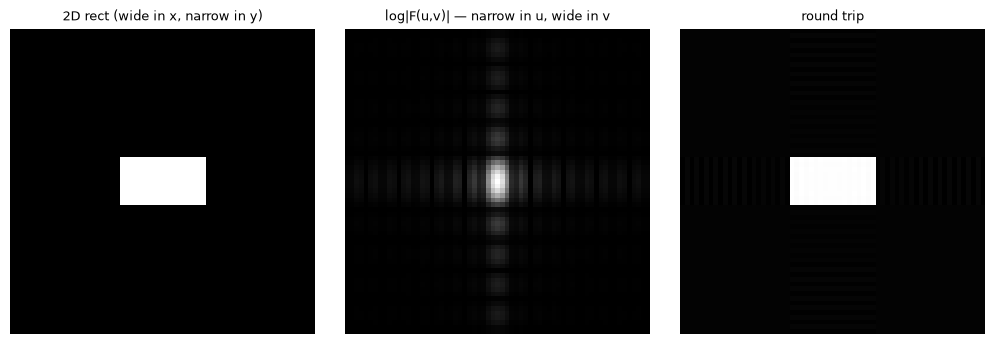

round-trip max error = 0.013802394518089262


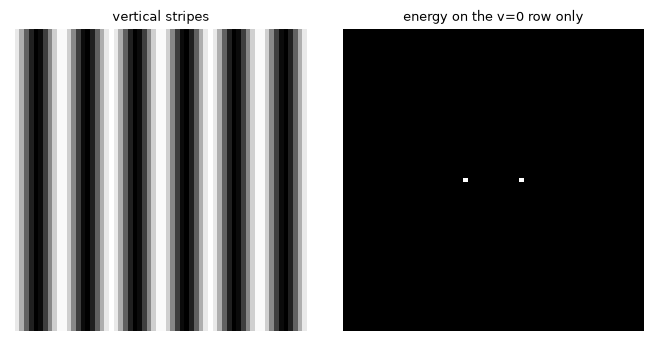

In [31]:
N2 = 64
gx, gy = np.meshgrid(np.linspace(-1, 1, N2), np.linspace(-1, 1, N2))
box = ((np.abs(gx) < 0.3) & (np.abs(gy) < 0.15)).astype(float)

img = Image2D(box)
c2 = CFT2D(img)
F = c2.transform()

show_images([(box, "2D rect (wide in x, narrow in y)"),
             (np.log1p(np.abs(F)), "log|F(u,v)| — narrow in u, wide in v"),
             (c2.inverse(F), "round trip")])
print("round-trip max error =", np.abs(c2.inverse(F) - box).max())

# stripes that vary only along x put all energy on the v = 0 row
stripes = np.cos(2 * np.pi * 3 * gx)
Fs = CFT2D(Image2D(stripes)).transform()
show_images([(stripes, "vertical stripes"), (np.log1p(np.abs(Fs)), "energy on the v=0 row only")])

## 6.2 2D shift and rotation

$$I(x-x_0,\,y-y_0)\;\longleftrightarrow\;F(u,v)\,e^{-j2\pi(ux_0+vy_0)}$$

**Magnitude is unchanged** — exactly as in 1D. This is why $|F|$ is a
translation-invariant signature of an image's content.

Rotation has no phase factor at all: rotating the image by $\theta$ rotates the
spectrum by the same $\theta$.

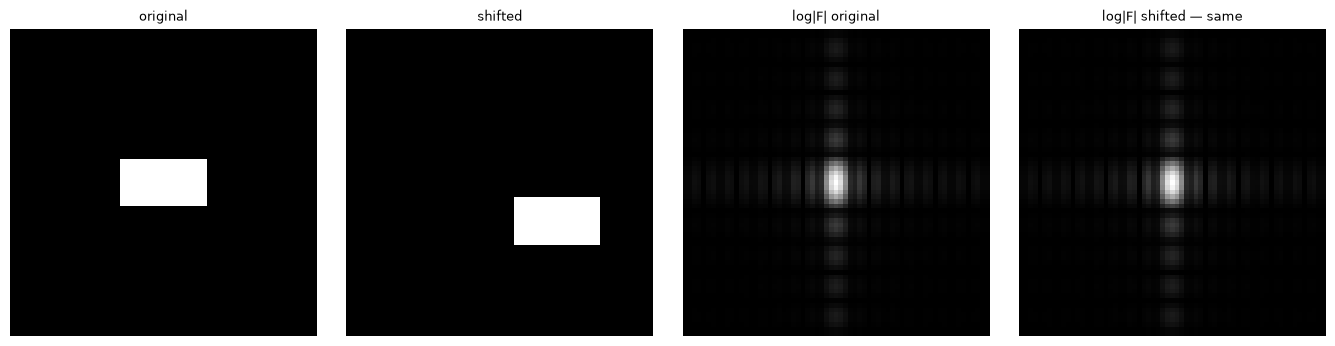

magnitude difference after shifting = 6.418476861114186e-17


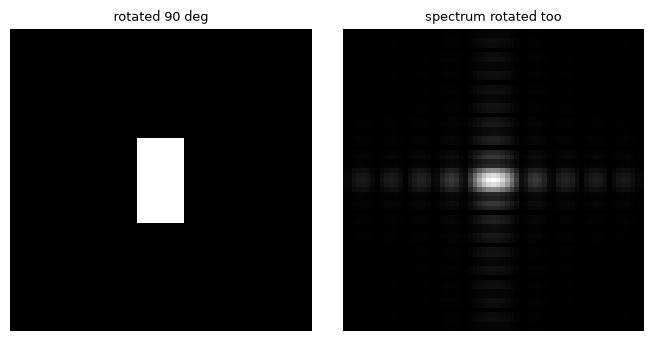

In [32]:
shifted = np.roll(box, (8, 12), axis=(0, 1))          # a shift on the pixel grid
Fsh = CFT2D(Image2D(shifted)).transform()
show_images([(box, "original"), (shifted, "shifted"),
             (np.log1p(np.abs(F)), "log|F| original"),
             (np.log1p(np.abs(Fsh)), "log|F| shifted — same")])
print("magnitude difference after shifting =", np.abs(np.abs(F) - np.abs(Fsh)).max())

rot = np.rot90(box)
Fr = CFT2D(Image2D(rot)).transform()
show_images([(rot, "rotated 90 deg"), (np.log1p(np.abs(Fr)), "spectrum rotated too")])

## 6.3 Filtering: low-pass blurs, high-pass finds edges

The convolution theorem in 2D: **multiply** the spectrum by a mask instead of
sliding a kernel over the image.

- **Low-pass** (keep small $\sqrt{u^2+v^2}$) — throws away fine detail: a blur.
- **High-pass** (drop small radii) — throws away the smooth interior and leaves
  the places where brightness changes fast: an **edge map**. This is the offline
  `cft_edge_detector` in one line.

After a high-pass the result contains negative values and is *not* a valid image
on its own — take `abs`, normalise, and usually invert so edges read dark.

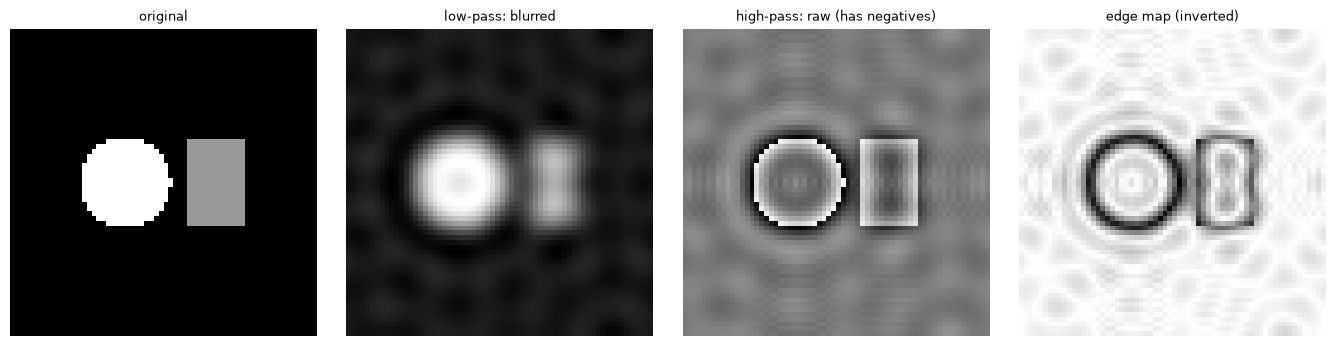

In [33]:
# a test picture with both smooth regions and sharp edges
disc = (((gx + 0.25) ** 2 + gy ** 2) < 0.09).astype(float)
pic = disc + 0.6 * ((np.abs(gx - 0.35) < 0.18) & (np.abs(gy) < 0.28))
imgp = Image2D(pic); cp = CFT2D(imgp); Fp = cp.transform()
U, V = np.meshgrid(cp.u, cp.v); R = np.sqrt(U ** 2 + V ** 2)

low = cp.inverse(np.where(R <= 3, Fp, 0))
high = cp.inverse(np.where(R > 3, Fp, 0))
edge = np.abs(high); edge = 1 - edge / edge.max()

show_images([(pic, "original"), (low, "low-pass: blurred"),
             (high, "high-pass: raw (has negatives)"), (edge, "edge map (inverted)")])

## 6.4 Denoising by band-stop — the 21A problem

The intercepted image is a letter buried under vertical stripes. Because the
stripes vary along $x$ only, their energy sits at **one horizontal frequency
$u$, spread across all $v$** — a vertical band of the spectrum, not a ring. So a
circular low/high-pass cannot remove them without destroying the letter; a
band-stop on $u$ can.

Two details that decide whether this works:

1. **Find the noise frequency, do not guess it.** Take the strongest $u$ that is
   *not* the DC lobe. Here DC is marginally stronger than the stripes, so a naive
   `argmax` would delete the average brightness and leave the noise untouched.
2. **Keep $u=0$.** It carries the average brightness.

noise peak at 2.491 stripes across the image
-> not an integer, so its energy leaks into harmonics 2 and 3; remove both


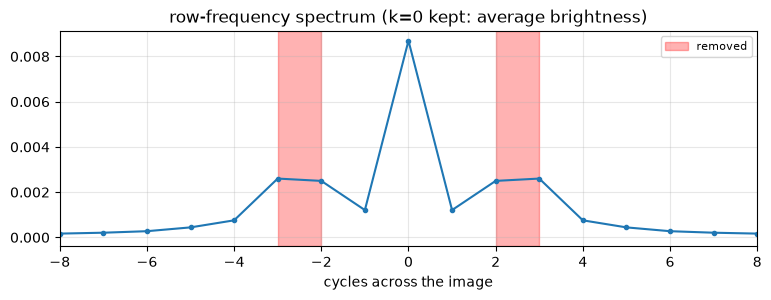

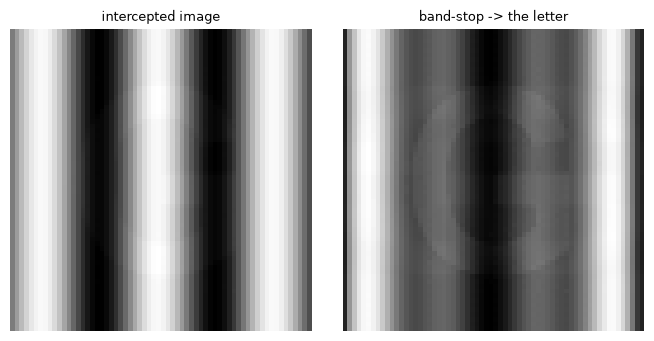

In [34]:
img_n = Image2D(path="noisy_image.png")
cn = CFT2D(img_n)
Fn = cn.transform()

strength = np.abs(Fn).mean(axis=0)                    # averaged over v
cycles = cn.u * img_n.Lx                              # in cycles across the image

# the CFT can be evaluated at ANY frequency, so scan a fine grid to find the
# true peak instead of settling for the nearest harmonic bin
scan = np.linspace(1.0, 8.0, 400) / img_n.Lx
mag = np.array([np.abs(np.trapezoid(img_n.image * np.exp(-2j * np.pi * s * img_n.x),
                                    img_n.x, axis=1)).mean() for s in scan])
peak = scan[np.argmax(mag)] * img_n.Lx
k_lo, k_hi = int(np.floor(peak)), int(np.ceil(peak))
print(f"noise peak at {peak:.3f} stripes across the image")
print(f"-> not an integer, so its energy leaks into harmonics {k_lo} and {k_hi}; remove both")

kill = (np.abs(cycles) >= k_lo - 0.1) & (np.abs(cycles) <= k_hi + 0.1)
Fc = Fn.copy(); Fc[:, kill] = 0
clean = cn.inverse(Fc)

plt.figure(figsize=(9, 2.8))
plt.plot(cycles, strength, marker=".")
plt.axvspan(k_lo, k_hi, color="r", alpha=.3, label="removed")
plt.axvspan(-k_hi, -k_lo, color="r", alpha=.3)
plt.xlim(-8, 8); plt.xlabel("cycles across the image"); plt.legend(fontsize=8)
plt.title("row-frequency spectrum (k=0 kept: average brightness)"); plt.show()

show_images([(img_n.image, "intercepted image"), (clean, "band-stop -> the letter")])

## 6.5 Blur as a multiplication (2D convolution theorem)

Convolving the image with a Gaussian kernel is the same as multiplying its
spectrum by the kernel's transform — which is another Gaussian. Cheaper, and it
makes "how blurry" a single tunable number.

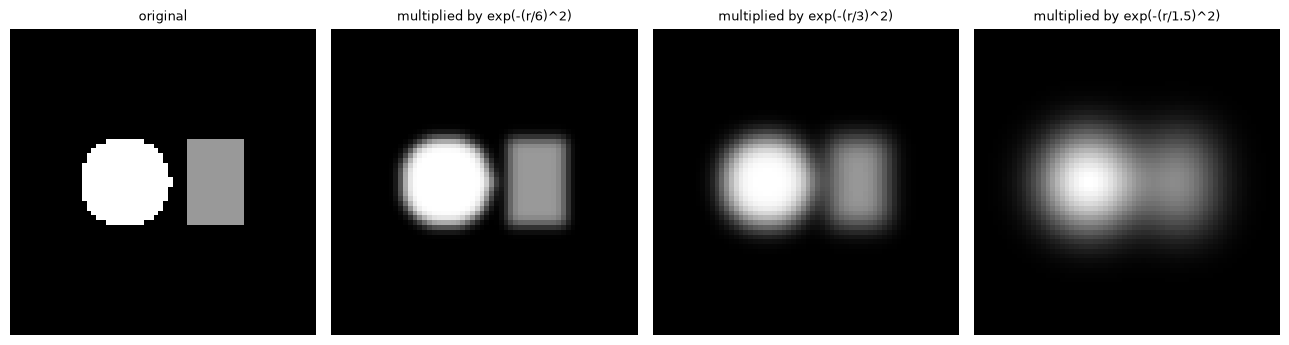

In [35]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
axes[0].imshow(pic, cmap="gray"); axes[0].set_title("original", fontsize=9); axes[0].axis("off")
for ax, s in zip(axes[1:], (6.0, 3.0, 1.5)):
    blurred = cp.inverse(Fp * np.exp(-(R / s) ** 2))    # Gaussian mask in frequency
    ax.imshow(blurred, cmap="gray"); ax.axis("off")
    ax.set_title(f"multiplied by exp(-(r/{s:g})^2)", fontsize=9)
plt.tight_layout(); plt.show()

---
# 7. Numerical gotchas checklist

Every one of these produced a wrong-looking answer at some point in the online
exams. Skim this before you submit.

**Setting up the axes**

1. **rad/s vs Hz.** If the question says $\cos(4t)$, that is $\omega=4$, so
   $f=4/2\pi\approx0.64$ Hz. Everything in this notebook is in Hz.
2. **Frequency range $\le$ Nyquist $=1/(2dt)$.** Past it you integrate aliased
   copies: reconstructions degrade and Parseval's energy inflates by an integer
   factor (§3, §4.12).
3. **Periodic signal $\Rightarrow$ window an exact integer number of periods.**
   Otherwise the transform leaks across neighbouring frequencies.
4. **Fourier series $\Rightarrow$ $t$ spans exactly one period.** And if you use
   the offline `FourierEpicycles`, it computes `self.T = t[-1]`, so your axis
   must *start at 0*. `FourierSeries` here uses `t[-1] - t[0]` instead.
5. **A time-limited signal makes the scaling property exact.** If the scaled
   signal no longer fits inside the window, the property will seem to fail.

**Phase**

6. **Always `wrap()` a phase difference** into $[-\pi,\pi)$. Raw differences come
   out as multiples of $2\pi$ and the MSE looks catastrophic (§4.2).
7. **Mask the phase where $|X|\approx0$.** The angle of numerical noise is
   uniformly random and will dominate any average.

**Reading results**

8. **Quote relative error for derivatives.** Order $n$ scales the spectrum by
   $(2\pi f)^n$, so the absolute MSE explodes while accuracy is unchanged.
9. **Amplitude $=2|c_n|$, sine phase $=\angle c_n+\pi/2$.** Forget the 2 and every
   amplitude is halved; forget the $\pi/2$ and every sine reads as $-\pi/2$.
10. **An all-imaginary spectrum means your signal is odd**, not that something
    broke.

**Python traps**

11. **`plt.plot` on a complex array** silently plots only the real part (with a
    `ComplexWarning`). For a pure-sine signal the real part is *zero*, so the plot
    looks empty. Always `np.abs(...)` or `np.angle(...)` first.
12. **`np.zeros_like(len(t))`** builds a 0-dimensional *integer* array, not a
    row of zeros — `np.zeros(len(t))` is what you want.
13. **Do not shift or scale by rolling arrays.** Several PDFs require the
    transformation to go through the class; `Signal` re-evaluates the callable,
    which is also exact rather than interpolated.
14. **Order matters when composing properties** — scale-then-modulate and
    modulate-then-scale give spectra centred at different places (§4.14).